Starting integrated run with Goldstone gauze...

DEBUG: Gauze model created with input_dim = 480
[q=0.10] Layer  51 (last 30) | Raw: 1.18e-15 | Gauze: 6.11e-16 | Dep: 6.18e-13
[q=0.10] Layer  52 (last 29) | Raw: 6.90e-16 | Gauze: 3.91e-15 | Dep: 4.70e-13
[q=0.10] Layer  53 (last 28) | Raw: 1.23e-15 | Gauze: 7.14e-15 | Dep: 5.64e-13
[q=0.10] Layer  54 (last 27) | Raw: 2.89e-15 | Gauze: 3.00e-14 | Dep: 3.35e-13
[q=0.10] Layer  55 (last 26) | Raw: 9.67e-15 | Gauze: 8.35e-14 | Dep: 3.95e-13
[q=0.10] Layer  56 (last 25) | Raw: 5.16e-14 | Gauze: 3.63e-13 | Dep: 3.90e-13
[q=0.10] Layer  57 (last 24) | Raw: 1.84e-13 | Gauze: 9.38e-13 | Dep: 3.36e-13
[q=0.10] Layer  58 (last 23) | Raw: 1.92e-13 | Gauze: 7.60e-13 | Dep: 6.93e-13
[q=0.10] Layer  59 (last 22) | Raw: 8.38e-13 | Gauze: 8.80e-12 | Dep: 6.55e-13
[q=0.10] Layer  60 (last 21) | Raw: 9.46e-13 | Gauze: 1.41e-11 | Dep: 5.88e-13
[q=0.10] Layer  61 (last 20) | Raw: 3.50e-12 | Gauze: 2.44e-11 | Dep: 4.35e-13
[q=0.10] Layer  62 (last 19) | Raw

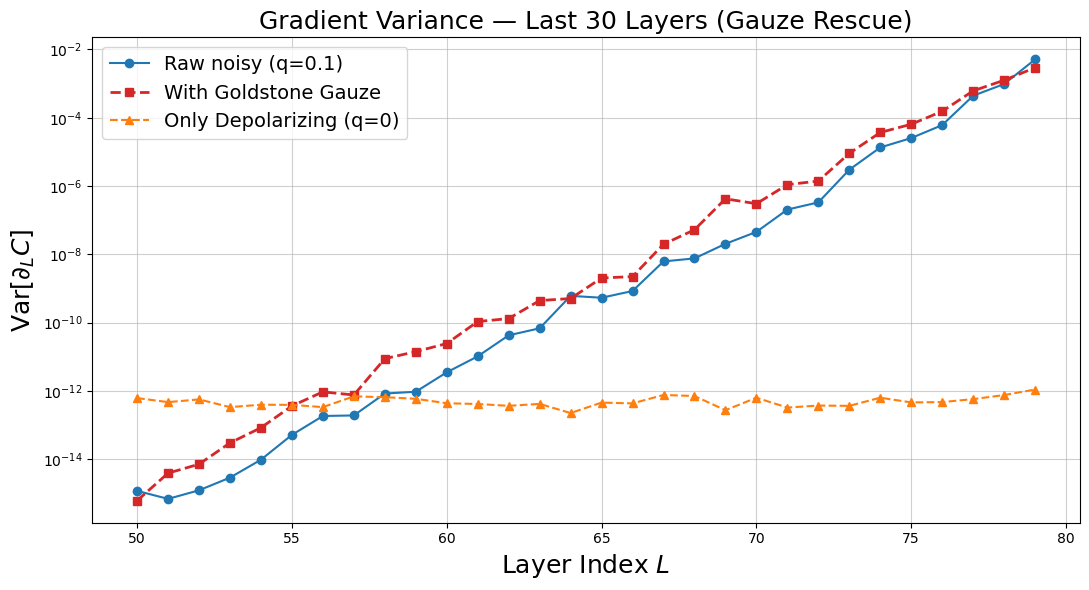


✅ Integration complete! The gauze is now running on top of your original circuit.


In [1]:
import pennylane as qml
from pennylane import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ====================== YOUR GOLDSTONE HYPER-HOLO GAUZE ======================
class GoldstoneHyperHoloBlock(nn.Module):
    def __init__(self, dim=72, depth=5, alpha=1.7, slip_factor=0.12, ng_strength=0.09):
        super().__init__()
        self.depth = depth
        self.alpha = alpha
        self.proj = nn.Linear(dim, dim)
        self.slip_gen = nn.Linear(dim, dim)
        self.holo_proj = nn.Linear(dim * 2, dim * 4)
        self.inv_holo = nn.Linear(dim * 4, dim)
        self.ng_proj = nn.Linear(dim, dim)
        self.ng_strength = ng_strength
        self.slip_factor = slip_factor
        self.norm_h = nn.LayerNorm(dim)
        self.norm_out = nn.LayerNorm(dim)

    def forward(self, x, level=0, t_step=0.0, training=False):
        if level >= self.depth:
            return x
        slip = torch.tanh(self.slip_gen(x)) * self.slip_factor
        h = torch.relu(self.proj(x + slip))
        h = self.norm_h(h)
        h_child = self.forward(h, level + 1, t_step, training)
        concat = torch.cat([h, h_child], dim=-1)
        boundary = self.holo_proj(concat)
        resolved = self.inv_holo(boundary)
        fb = resolved * h

        if training:
            vev_rand = torch.tanh(torch.randn_like(h.mean(dim=-1, keepdim=True)))
            phase_noise = torch.randn_like(h) * 0.15
            vev_scale = 0.005
            phase_scale = 1.0
        else:
            vev_rand = torch.randn_like(h.mean(dim=-1, keepdim=True)) * 0.3
            phase_noise = torch.randn_like(h) * 0.08
            vev_scale = 0.0025
            phase_scale = 0.6

        vev = torch.norm(h, dim=-1, keepdim=True) * vev_scale * torch.tanh(vev_rand)
        h_broken = h + vev
        proj = self.ng_proj(h_broken)
        norm_hb_sq = h_broken.norm(dim=-1, keepdim=True)**2 + 1e-8
        dot = (proj * h_broken).sum(-1, keepdim=True) / norm_hb_sq
        goldstone = proj - dot * h_broken

        phase = torch.sin(t_step * 2.0 * np.pi + phase_noise * phase_scale)
        h = h + self.ng_strength * goldstone * phase
        h = self.norm_h(h)

        out = x + fb + 0.04 * h_child
        if training:
            mask_prob = max(0.1, 1.0 / ((level + 1) ** self.alpha))
            mask = (torch.rand_like(out) < mask_prob).float()
            out = out * mask
        out = self.norm_out(out)
        return out


class CoherenceNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=72):
        super().__init__()
        self.embed = nn.Linear(input_dim, hidden_dim)
        self.fractal_core = GoldstoneHyperHoloBlock(hidden_dim)
        self.head = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, steps=1, training=False):
        h = self.embed(x)
        for t in range(steps):
            h = self.fractal_core(h, t_step=t / max(1, steps), training=training)
        return self.head(h)


class KernelGauzeWrapper:
    def __init__(self):
        self.model = None

    def apply_gauze(self, params_last_LL):
        flat_size = params_last_LL.size
        if self.model is None or self.model.embed.in_features != flat_size:
            self.model = CoherenceNet(input_dim=flat_size)
            print(f"DEBUG: Gauze model created with input_dim = {flat_size}")
        flat = torch.from_numpy(params_last_LL.reshape(-1).astype(np.float32)).unsqueeze(0)
        with torch.no_grad():
            filtered = self.model(flat, steps=1, training=False)
        return filtered.view(params_last_LL.shape).numpy()


# ====================== YOUR ORIGINAL SCRIPT (with gauze added) ======================
nmax = 4
reps = 30          # increased for cleaner variance
epsd = 1e-7
LL = 30
p = 0.02
q_value = 0.1      # change this to test different non-unital strengths
columsperlayer = 4
nqubits = nmax
depth = 20 * nqubits

dev = qml.device('default.mixed', wires=nqubits)

def create_circuit(nqubits, depth, p, q):
    @qml.qnode(dev)
    def circuit(params):
        for L in range(depth):
            for i in range(nqubits):
                qml.RX(params[i, 0, L], wires=i)
            for i in range(nqubits // 2):
                qml.CNOT(wires=[2 * i, 2 * i + 1])
            for i in range(nqubits):
                qml.RY(params[i, 1, L], wires=i)
                qml.DepolarizingChannel(p, wires=i)
                qml.AmplitudeDamping(q, wires=i)
            for i in range(nqubits):
                qml.RX(params[i, 2, L], wires=i)
            for i in range(nqubits // 2 - 1 + int(nqubits % 2)):
                qml.CNOT(wires=[2 * i + 1, 2 * i + 2])
            for i in range(nqubits):
                qml.RY(params[i, 3, L], wires=i)
                qml.DepolarizingChannel(p, wires=i)
                qml.AmplitudeDamping(q, wires=i)
        return qml.expval(qml.PauliZ(0))
    return circuit


def compute_variances(q_value):
    circuit = create_circuit(nqubits, depth, p, q_value)
    circuit_q0 = create_circuit(nqubits, depth, p, 0)

    var_list, var_gauze_list, var_q0_list = [], [], []
    last_layers = range(depth - LL, depth)

    kernel_wrapper = KernelGauzeWrapper()

    for pd in last_layers:
        grad_points = []
        grad_gauze_points = []
        grad_q0_points = []

        for _ in range(reps):
            params = 2 * np.pi * np.random.rand(nqubits, columsperlayer, depth)

            # Raw noisy
            pdx = np.copy(params)
            psx = np.copy(params)
            pdx[0, -1, pd] += epsd
            psx[0, -1, pd] -= epsd
            grad_points.append((circuit(pdx) - circuit(psx)) / (2 * epsd))

            # Gauze on last LL layers
            params_last = params[:, :, -LL:].copy()
            gauze_last = kernel_wrapper.apply_gauze(params_last)
            pdx_g = np.copy(params)
            psx_g = np.copy(params)
            pdx_g[:, :, -LL:] = gauze_last
            pdx_g[0, -1, pd] += epsd
            psx_g[:, :, -LL:] = gauze_last
            psx_g[0, -1, pd] -= epsd
            grad_gauze_points.append((circuit(pdx_g) - circuit(psx_g)) / (2 * epsd))

            # Baseline (only depolarizing)
            grad_q0_points.append((circuit_q0(pdx) - circuit_q0(psx)) / (2 * epsd))

        var_list.append(np.var(grad_points, ddof=1))
        var_gauze_list.append(np.var(grad_gauze_points, ddof=1))
        var_q0_list.append(np.var(grad_q0_points, ddof=1))

        print(f"[q={q_value:.2f}] Layer {pd+1:3d} (last {depth-pd:2d}) | "
              f"Raw: {var_list[-1]:.2e} | Gauze: {var_gauze_list[-1]:.2e} | Dep: {var_q0_list[-1]:.2e}")

    return var_list, var_gauze_list, var_q0_list


# ====================== RUN ======================
print("Starting integrated run with Goldstone gauze...\n")
var, var_gauze, var_q0 = compute_variances(q_value)

# ====================== PLOT ======================
x = np.arange(depth - LL, depth)
plt.figure(figsize=(11, 6))
plt.plot(x, var, 'o-', label=f'Raw noisy (q={q_value})', color='tab:blue')
plt.plot(x, var_gauze, 's--', label='With Goldstone Gauze', color='tab:red', linewidth=2)
plt.plot(x, var_q0, '^--', label='Only Depolarizing (q=0)', color='tab:orange')
plt.xlabel('Layer Index $L$', fontsize=18)
plt.ylabel(r'$\mathrm{Var}[\partial_L C]$', fontsize=18)
plt.title(f'Gradient Variance — Last {LL} Layers (Gauze Rescue)', fontsize=18)
plt.yscale('log')
plt.legend(fontsize=14)
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

print("\n✅ Integration complete! The gauze is now running on top of your original circuit.")